# Retrieval-Vergleich: BM25S vs. Embeddings

Gleiches Korpus, gleiche Queries, zwei Retrieval-Verfahren:

- **BM25S** – term-based, zaehlt Wortueberlappung zwischen Query und Chunk (lexikalisch)
- **Embeddings** – dense, vergleicht Vektoren im semantischen Raum

Korpus: `AfD_Parteiprogramm2026.txt`, gechunkt nach Saetzen.

In [ ]:
# Einmalig installieren, falls noch nicht vorhanden:
# %pip install bm25s PyStemmer sentence-transformers pandas numpy

In [131]:
from pathlib import Path

import numpy as np
import pandas as pd
import re 


import matplotlib.pyplot as plt

with open("AfD_Parteiprogramm2026.txt", "r", encoding="utf-8") as f:
    TXT_PATH = f.read()

TOP_K = 5
MIN_CHARS = 50   # sehr kurze Fragmente rausfiltern

MAX_CHARS = 1000  # sehr lange Fragmente rausfiltern


### Chunking the party programm


In [132]:
# creation of chunks from the text file
TXT_PATH = text = re.sub(r"[^\S]+", " ", TXT_PATH)  # replace multiple spaces with a single space
chunks = TXT_PATH.replace("\n", " ").strip().split(".")

len_chunks = [ len(c) for c in chunks]  # Wörter
# len_chunks_token = [len(enc.encode(c)) for c in chunks]  # Tokens, z.B. tiktoken


print(f"Number of chunks: {len(chunks)}")
print(f"Lengths chunks: {len_chunks}")

chunk_size_filter = lambda x: len(x) > MIN_CHARS and len(x) < MAX_CHARS


Number of chunks: 1875
Lengths chunks: [24, 54, 47, 47, 39, 40, 34, 37, 1, 57, 1, 41, 1, 36, 1, 55, 1, 54, 27, 1, 48, 1, 88, 33, 53, 52, 36, 89, 49, 85, 49, 36, 47, 33, 53, 54, 105, 36, 36, 47, 25, 1, 30, 1, 35, 62, 53, 74, 30, 44, 1, 58, 1, 61, 1, 66, 1, 67, 57, 43, 38, 52, 50, 31, 22, 85, 54, 51, 57, 63, 68, 63, 1, 44, 1, 40, 1, 48, 1, 77, 1, 92, 55, 1, 48, 1, 47, 1, 57, 1, 35, 53, 1, 51, 1, 57, 1, 50, 1, 78, 1, 52, 1, 34, 40, 1, 24, 51, 1, 49, 60, 1, 70, 1, 141, 55, 1, 52, 1, 68, 34, 47, 48, 55, 73, 111, 51, 52, 56, 42, 26, 56, 56, 56, 57, 55, 2, 49, 2, 65, 2, 51, 52, 2, 40, 2, 54, 2, 60, 2, 84, 46, 42, 35, 74, 39, 56, 50, 49, 39, 61, 69, 59, 62, 121, 71, 78, 38, 96, 40, 55, 33, 17, 18, 33, 27, 60, 150, 48, 59, 53, 76, 55, 48, 65, 73, 57, 31, 35, 37, 31, 171, 177, 219, 209, 184, 133, 207, 115, 311, 172, 73, 238, 469, 66, 343, 76, 78, 76, 144, 190, 97, 70, 169, 262, 90, 57, 158, 89, 156, 99, 182, 129, 129, 100, 168, 122, 71, 154, 109, 63, 101, 111, 146, 2, 98, 56, 106, 115, 81, 30, 1

In [134]:
chunks = list(filter(chunk_size_filter, chunks))

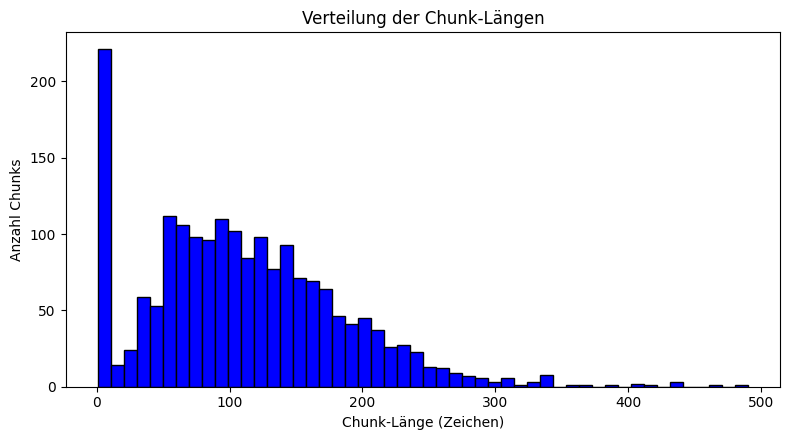

In [135]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(len_chunks, bins=50, color= "blue", edgecolor="black")

#ax.axvline(med, color="#E45756", linestyle="--", linewidth=1.5, label=f"Median: {med:.0f}")

ax.set_xlabel("Chunk-Länge (Zeichen)")
ax.set_ylabel("Anzahl Chunks")
ax.set_title(f"Verteilung der Chunk-Längen")
fig.tight_layout()
plt.show()


## <u>1. BM25S – term-based retrieval </u>

BM25 bewertet, wie oft Query-Terme im Chunk vorkommen, gewichtet nach Seltenheit
des Terms im Korpus (IDF) und normiert auf die Chunk-Laenge.

Der Stemmer ist bei Deutsch wichtig: ohne ihn matcht `Klimaschutz` nicht auf
`Klimaschutzpolitik` und `Steuern` nicht auf `Steuer`.

In [136]:
import bm25s

try:
    import Stemmer
    stemmer = Stemmer.Stemmer("german")
    print("Geil, import von PyStemmer hat geklappt !")
except ImportError:
    stemmer = None
    print("PyStemmer nicht installiert - laeuft ohne Stemming (schwaechere Treffer)")

corpus_tokens = bm25s.tokenize(chunks)

bm25 = bm25s.BM25()
bm25.index(corpus_tokens)
print("BM25-Index gebaut")

Geil, import von PyStemmer hat geklappt !


Split strings:   0%|          | 0/1497 [00:00<?, ?it/s]

BM25S Count Tokens:   0%|          | 0/1497 [00:00<?, ?it/s]

BM25S Compute Scores:   0%|          | 0/1497 [00:00<?, ?it/s]

BM25-Index gebaut


In [139]:
query = "Umwelt"

term_vector= bm25s.tokenize(query, stopwords="de", stemmer=stemmer)
results, scores = bm25.retrieve(term_vector, corpus=chunks, k=5)
for i, res in enumerate(results[0]):
    print(f'Result {i+1}: {res} \n')

Split strings:   0%|          | 0/1 [00:00<?, ?it/s]

Stem Tokens:   0%|          | 0/1 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]

Result 1: 1 Klimaschutzpolitik: Irrweg beenden, Umwelt schützen 79 12 

Result 2: 1 Intakte Natur und gesunde Umwelt Die AfD steht für einen Umwelt- und Naturschutz, der den Menschen nicht als Fremdkörper und Störenfried betrachtet, sondern in ein umfassendes Handlungskonzept einbezieht 

Result 3:  Der Betrieb solcher Anlagen im ländlichen Raum belastet häufig die Umwelt 

Result 4: 1 Klimaschutzpolitik: Irrweg beenden, Umwelt schützen Das Klima wandelt sich, solange die Erde existiert 

Result 5:  Eine gesunde Umwelt ist die Lebensgrundlage für alle Menschen und zukünftige Gene rationen 



In [141]:
from bm25s import BM25

In [143]:
def search_bm25(query: str, k: int = TOP_K):
    """Gibt (indices, scores) der k besten Chunks zurueck."""
    query_tokens = bm25s.tokenize(query, stopwords="de", show_progress=False)
    idx, scores = bm25s.retrieve(query_tokens, k=k, show_progress=False)
    return idx[0], scores[0]


query = "Was ist die Stellungnahme der Partei zum Klimaschutz?"

idx, scores = search_bm25(query)
for i, s in zip(idx, scores):
    print(f"{s:6.2f}  {chunks[i][:140]}")

AttributeError: module 'bm25s' has no attribute 'retrieve'

## <u>2. Embeddings – embedding-based retrieval</u>

`paraphrase-multilingual-MiniLM-L12-v2` ist auf mehrsprachigen Paaren trainiert und
versteht Deutsch. Mit `normalize_embeddings=True` sind alle Vektoren auf Laenge 1,
dann ist das Skalarprodukt direkt die Kosinus-Aehnlichkeit.

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

embeddings = model.encode(
    chunks,
    batch_size=64,
    normalize_embeddings=True,
    show_progress_bar=True,
)
print(embeddings.shape)   # (n_chunks, 384)

In [ ]:
def search_embed(query: str, k: int = TOP_K):
    """Gibt (indices, scores) der k aehnlichsten Chunks zurueck."""
    q = model.encode([query], normalize_embeddings=True)[0]
    sims = embeddings @ q              # Kosinus-Aehnlichkeit, da normalisiert
    idx = np.argsort(-sims)[:k]
    return idx, sims[idx]


query = "Was ist die Stellungnahme der Partei zum Klimaschutz?"

idx, scores = search_embed(query)
for i, s in zip(idx, scores):
    print(f"{s:6.3f}  {chunks[i][:140]}")

## 4. Vergleich

Die Scores der beiden Verfahren sind **nicht** vergleichbar: BM25 ist unbeschraenkt
nach oben, Kosinus liegt zwischen -1 und 1. Vergleichbar ist nur, *welche* Chunks
oben stehen. Dafuer der Overlap: wie viele der Top-k finden beide Verfahren.

In [ ]:
QUERIES = [
    "Was ist die Stellungnahme der Partei zum Klimaschutz?",
    "Wie steht die Partei zur Europaeischen Union?",
    "Welche Position vertritt die Partei bei der Rente?",
    "Zuwanderung und Asylpolitik",
    "Digitalisierung und kuenstliche Intelligenz",
]


def compare(query: str, k: int = TOP_K, width: int = 110) -> pd.DataFrame:
    b_idx, b_scores = search_bm25(query, k)
    e_idx, e_scores = search_embed(query, k)

    return pd.DataFrame({
        "rank":       range(1, k + 1),
        "bm25_score": np.round(b_scores, 2),
        "bm25_chunk": [chunks[i][:width] for i in b_idx],
        "emb_score":  np.round(e_scores, 3),
        "emb_chunk":  [chunks[i][:width] for i in e_idx],
    }).set_index("rank")


pd.set_option("display.max_colwidth", 120)
compare(QUERIES[0])

In [ ]:
rows = []
for q in QUERIES:
    b_idx, _ = search_bm25(q)
    e_idx, _ = search_embed(q)
    shared = set(b_idx.tolist()) & set(e_idx.tolist())
    rows.append({
        "query": q,
        "overlap": len(shared),
        "overlap_pct": f"{len(shared) / TOP_K:.0%}",
    })

pd.DataFrame(rows)

In [ ]:
# Einzelne Query im Detail anschauen
compare(QUERIES[3])

## Was du in den Ergebnissen sehen solltest

BM25 gewinnt, wenn die Query die Begriffe des Texts woertlich enthaelt, und faellt
aus, sobald du umschreibst. Embeddings finden Umschreibungen, holen aber auch
thematisch benachbarte Chunks, die die Frage nicht beantworten.

Der Satz-Split hat zwei bekannte Schwaechen, die du in den Treffern siehst:
Abkuerzungen und Gliederungsnummern (`12.1 Klimaschutzpolitik`) werden
faelschlich getrennt, und ein einzelner Satz ist oft zu wenig Kontext fuer eine
Antwort. Naechster Schritt waere ein Sliding Window ueber je 3 Saetze mit einem
Satz Ueberlappung, dann laesst sich messen, ob die Trefferqualitaet steigt.